# Image Processing

# Importing Image

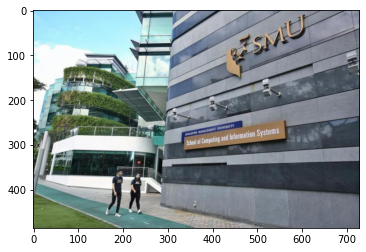

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

scis1 = Image.open('../data/scis1.jpeg')
plt.imshow(scis1)
plt.show()

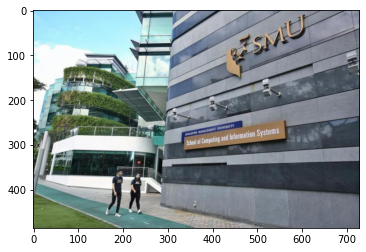

In [26]:
from skimage import io
import matplotlib.pyplot as plt

scis1 = io.imread('../data/scis1.jpeg')
plt.imshow(scis1)
plt.show()

## Common Operations

Original size: (729, 486)
New size: (360, 240)


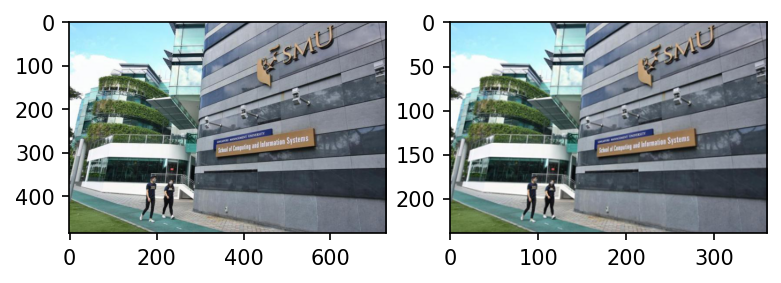

In [27]:
# Resize
from PIL import Image
import matplotlib.pyplot as plt

scis1 = Image.open('../data/scis1.jpeg')

scis1_sm = scis1.resize((360, 240))

print(f"Original size: {scis1.size}")
print(f"New size: {scis1_sm.size}")
# Original size: (729, 486)
# New size: (360, 240)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(scis1)
axs[1].imshow(scis1_sm)


fig.set_dpi(150)
plt.show()

## Gray Scale Image

Shape: (486, 729), Data Type: uint8


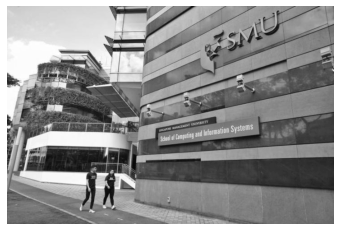

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')

gray = np.array(scis1.convert('L'))
print(f'Shape: {gray.shape}, Data Type: {gray.dtype}')
# Shape: (486, 729), Data Type: uint8

plt.imshow(gray)
plt.axis('off')
plt.gray()
plt.show()

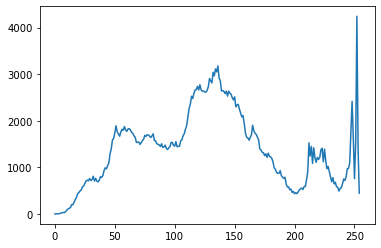

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')

gray = np.array(scis1.convert('L'))

histogram, bins = np.histogram(gray, bins=255, range=(0, 255))
plt.plot(bins[:-1], histogram)
plt.show()

## RGB Image and Histogram

Shape: (486, 729, 3), Data Type: uint8


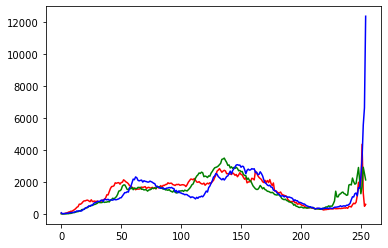

In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')
a = np.array(scis1)
print(f'Shape: {a.shape}, Data Type: {a.dtype}')

hist_r, bins = np.histogram(a[:,:,0], bins=255, range=(0, 255))
hist_g, bins = np.histogram(a[:,:,1], bins=255, range=(0, 255))
hist_b, bins = np.histogram(a[:,:,2], bins=255, range=(0, 255))
plt.plot(bins[:-1], hist_r, color='r')
plt.plot(bins[:-1], hist_g, color='g')
plt.plot(bins[:-1], hist_b, color='b')
plt.show()

# Smoothing with a Gaussian Filter

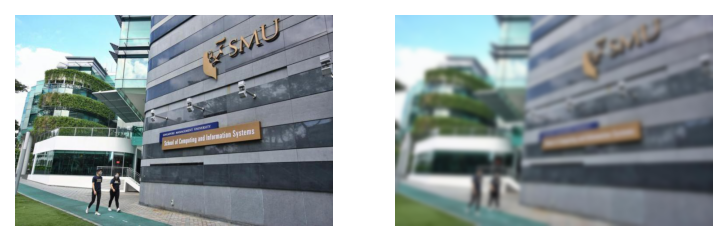

In [52]:
# Gaussian Filter
from scipy.ndimage import gaussian_filter

a1 = np.array(scis1)
a2 = gaussian_filter(a1, sigma=(5, 5, 0))

fig, axs = plt.subplots(1, 2)
fig.set_dpi(150)
axs[0].imshow(a1)
axs[1].imshow(a2)

axs[0].axis('off')
axs[1].axis('off')

plt.show()

# Edge Detection with a Sobel Filter

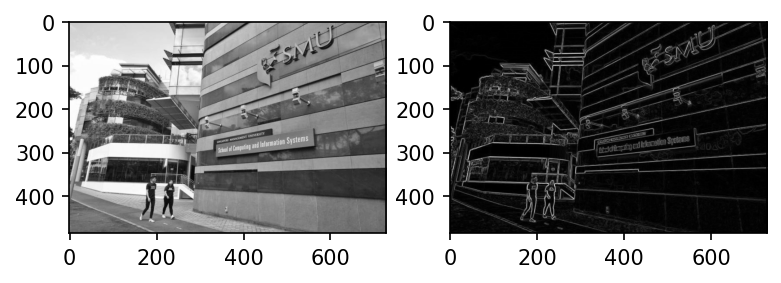

In [53]:
# Sobel filter
from skimage.filters import sobel

gray = np.array(scis1.convert('L'))

fig, axs = plt.subplots(1, 2)
fig.set_dpi(150)

axs[0].imshow(gray)
axs[1].imshow(sobel(gray))

plt.show()

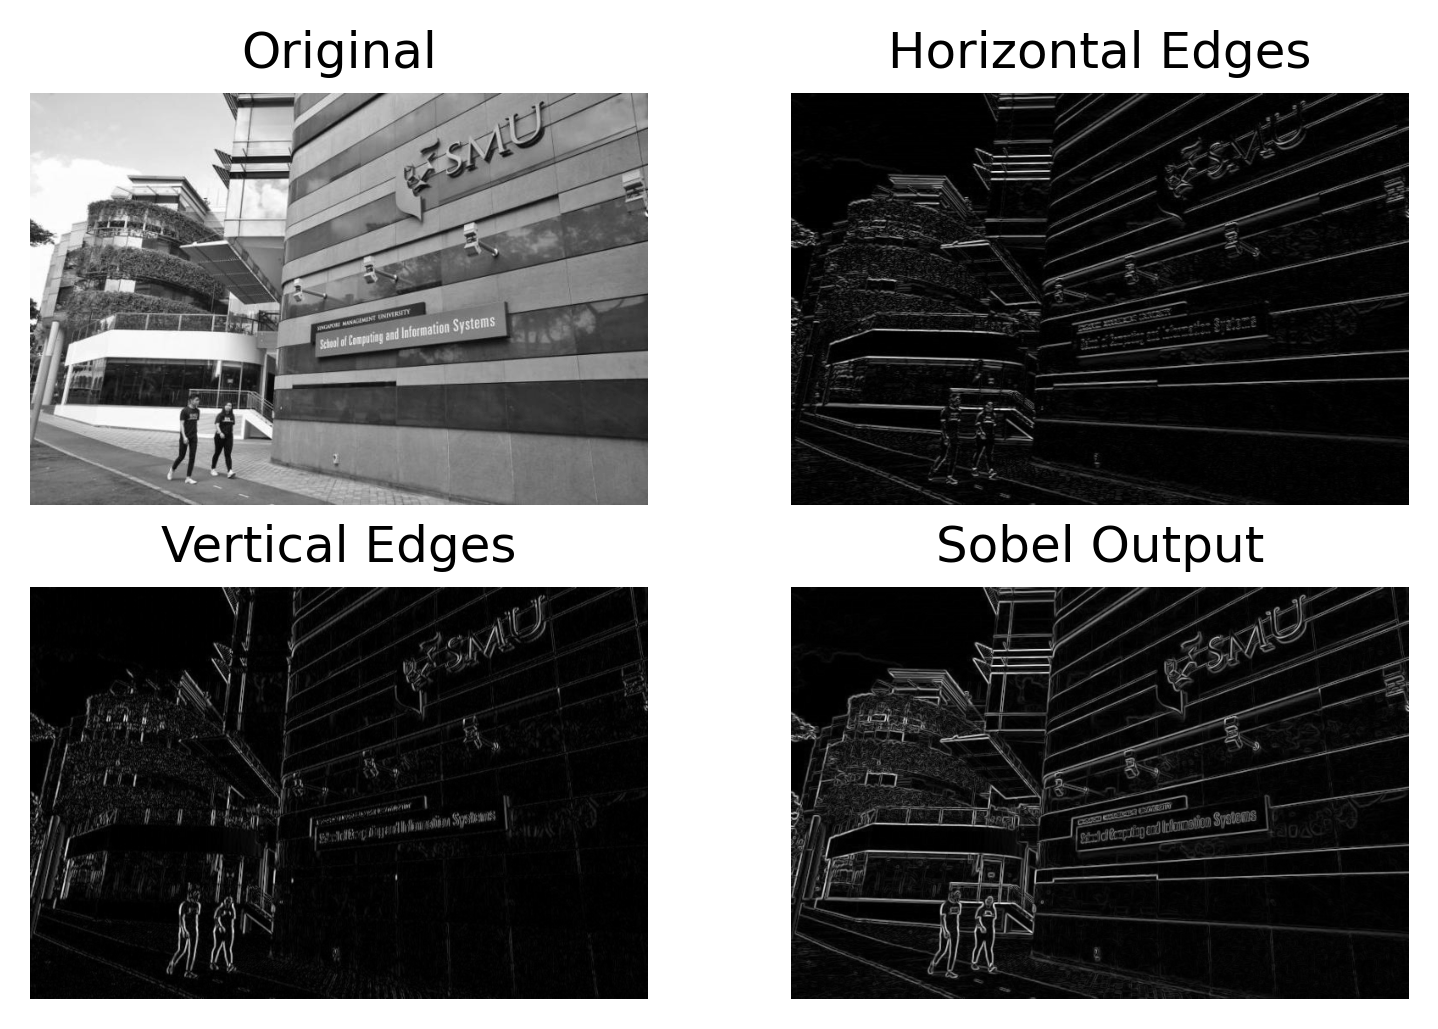

In [54]:
# Sobel filter 2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi


scis1 = Image.open('../data/scis1.jpeg')

gray = np.array(scis1.convert('L'))
gray = gray.astype(float) / 255

hsobel = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])
vsobel = hsobel.T

horizontal = ndi.convolve(gray, hsobel)
vertical = ndi.convolve(gray, vsobel)

# sobel_result = np.sqrt(horizontal**2 + vertical**2)
sobel_result = np.hypot(horizontal, vertical)

fig, axs = plt.subplots(2, 2)
fig.set_dpi(300)

axs[0, 0].imshow(gray)
axs[0, 1].imshow(np.abs(horizontal), cmap='gray')
axs[1, 0].imshow(np.abs(vertical), cmap='gray')
axs[1, 1].imshow(sobel_result)

axs[0, 0].axis('off')
axs[0, 1].axis('off')
axs[1, 0].axis('off')
axs[1, 1].axis('off')

axs[0, 0].set_title('Original')
axs[0, 1].set_title('Horizontal Edges')
axs[1, 0].set_title('Vertical Edges')
axs[1, 1].set_title('Sobel Output')
plt.show()

# Harris Corner Detector

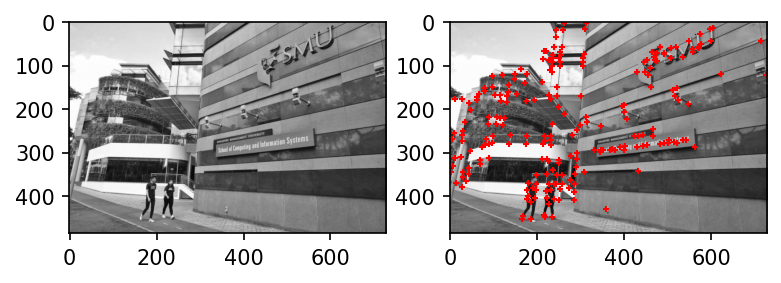

In [55]:
from skimage.feature import corner_harris, corner_subpix, corner_peaks

gray = np.array(scis1.convert('L'))

coords = corner_peaks(corner_harris(gray), min_distance=5, threshold_rel=0.02)
coords_subpix = corner_subpix(gray, coords, window_size=13)


fig, axs = plt.subplots(1, 2)
fig.set_dpi(150)

axs[0].imshow(gray, cmap=plt.cm.gray)
axs[1].imshow(gray, cmap=plt.cm.gray)
axs[1].plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=3)

plt.show()